<a href="https://colab.research.google.com/github/melia1702/pertemuan-kesebelas/blob/main/Praktikum_11_2_MG_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

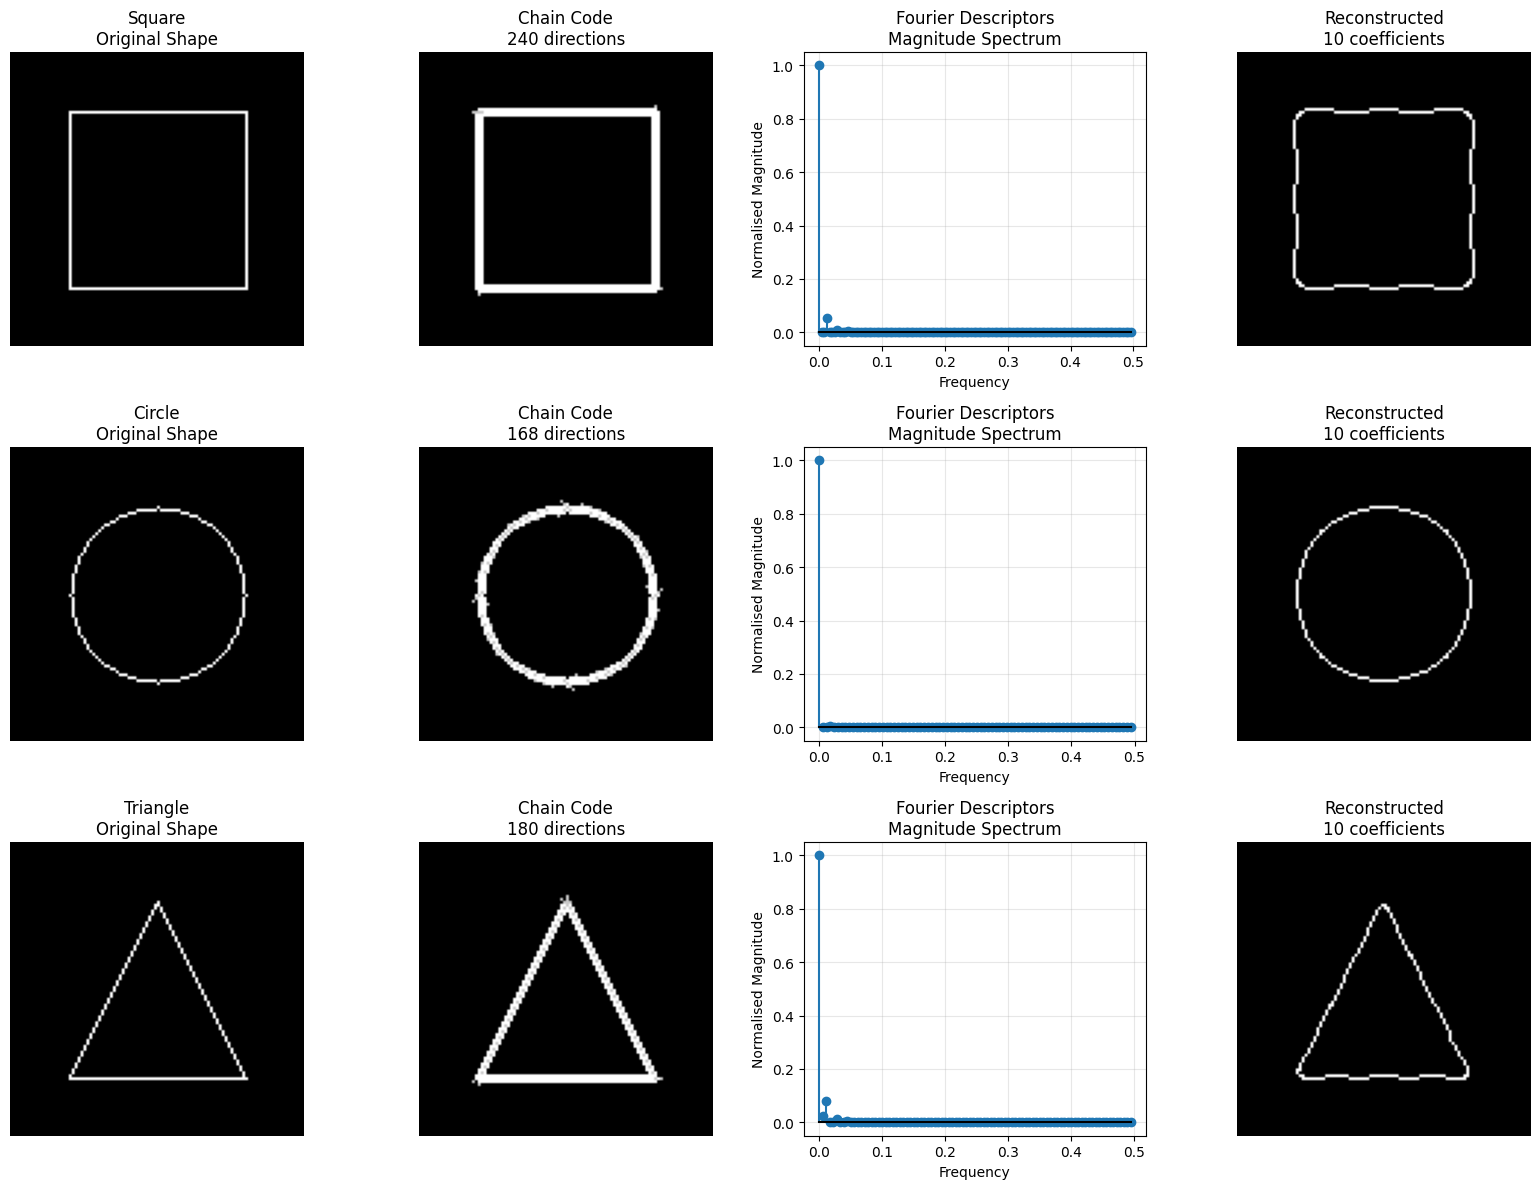

CHAIN CODE ANALYSIS

Square:
  Number of chain codes : 240
  First 10 codes        : [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
  Direction frequency   :
    East  : 60
    South : 60
    West  : 60
    North : 60

Circle:
  Number of chain codes : 168
  First 10 codes        : [3, 4, 4, 4, 4, 4, 4, 3, 4, 4]
  Direction frequency   :
    East  : 24
    SE    : 18
    South : 24
    SW    : 18
    West  : 24
    NW    : 18
    North : 24
    NE    : 18

Triangle:
  Number of chain codes : 180
  First 10 codes        : [3, 2, 3, 2, 3, 2, 3, 2, 3, 2]
  Direction frequency   :
    East  : 60
    South : 30
    SW    : 30
    NW    : 30
    North : 30

FOURIER DESCRIPTORS FOR SHAPE MATCHING
Shape similarity (Euclidean distance between Fourier descriptors):
  Square vs Circle: 0.0519
  Square vs Triangle: 0.1011
  Circle vs Triangle: 0.0860

Interpretation:
  • Smaller distance = more similar shapes
  • Larger distance  = less similar shapes
  • Fourier descriptors are invariant to rotation and scale


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# Helper functions (defined at module level)
# ─────────────────────────────────────────────

def freeman_chain_code_8dir(points):
    """Calculate 8-directional Freeman chain code."""
    if len(points) < 2:
        return []

    directions_8 = [
        (1,  0),   # 0: East
        (1,  1),   # 1: Southeast
        (0,  1),   # 2: South
        (-1, 1),   # 3: Southwest
        (-1, 0),   # 4: West
        (-1,-1),   # 5: Northwest
        (0, -1),   # 6: North
        (1, -1),   # 7: Northeast
    ]

    chain_code = []
    for i in range(len(points)):
        current    = points[i]
        next_point = points[(i + 1) % len(points)]

        dx = int(next_point[0]) - int(current[0])
        dy = int(next_point[1]) - int(current[1])

        for dir_code, (dir_dx, dir_dy) in enumerate(directions_8):
            if dx == dir_dx and dy == dir_dy:
                chain_code.append(dir_code)
                break
        # If no exact match found (diagonal skip), just continue

    return chain_code


def compute_fourier_descriptors(points):
    """Compute Fourier descriptors from boundary points."""
    z = points[:, 0] + 1j * points[:, 1]
    fd = np.fft.fft(z)
    fd_magnitude = np.abs(fd)

    # Normalize by DC component
    if fd_magnitude[0] != 0:
        fd_normalized = fd_magnitude / fd_magnitude[0]
    else:
        fd_normalized = fd_magnitude

    return fd, fd_normalized


def reconstruct_shape(fd, num_coeffs):
    """Reconstruct shape using only the lowest-frequency Fourier coefficients."""
    fd_recon = fd.copy()
    # Zero out everything except the first and last num_coeffs entries
    fd_recon[num_coeffs : len(fd_recon) - num_coeffs] = 0
    z_recon = np.fft.ifft(fd_recon)
    return z_recon.real, z_recon.imag


def get_simple_contour(shape):
    """Extract and de-duplicate contour points from a binary shape image."""
    contours, _ = cv2.findContours(shape, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    contour = contours[0]

    contour_simple = []
    for i in range(len(contour)):
        if i == 0 or not np.array_equal(contour[i][0], contour[i - 1][0]):
            contour_simple.append(contour[i][0])

    return np.array(contour_simple)


# ─────────────────────────────────────────────
# Main function
# ─────────────────────────────────────────────

def latihan_2():
    # --- Build shapes ---
    shapes = []

    square = np.zeros((100, 100), dtype=np.uint8)
    cv2.rectangle(square, (20, 20), (80, 80), 255, 1)
    shapes.append(('Square', square))

    circle = np.zeros((100, 100), dtype=np.uint8)
    cv2.circle(circle, (50, 50), 30, 255, 1)
    shapes.append(('Circle', circle))

    triangle = np.zeros((100, 100), dtype=np.uint8)
    pts = np.array([[50, 20], [20, 80], [80, 80]])
    cv2.polylines(triangle, [pts], True, 255, 1)
    shapes.append(('Triangle', triangle))

    # --- Plot: 3 rows × 4 columns ---
    #   col 0 : original shape
    #   col 1 : chain-code visualisation
    #   col 2 : Fourier magnitude spectrum
    #   col 3 : reconstructed shape (best coefficient count)
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))

    for row, (name, shape) in enumerate(shapes):
        contour_simple = get_simple_contour(shape)

        # ── Col 0: Original shape ──────────────────────────────────────────
        axes[row, 0].imshow(shape, cmap='gray')
        axes[row, 0].set_title(f'{name}\nOriginal Shape')
        axes[row, 0].axis('off')

        # ── Col 1: Chain code visualisation ───────────────────────────────
        chain_code = freeman_chain_code_8dir(contour_simple)

        chain_display = np.zeros((100, 100), dtype=np.uint8)
        directions = [(1,0),(1,1),(0,1),(-1,1),(-1,0),(-1,-1),(0,-1),(1,-1)]

        for i, point in enumerate(contour_simple):
            cv2.circle(chain_display, tuple(point), 1, 255, -1)
            if i < len(chain_code):
                dx, dy = directions[chain_code[i]]
                end_point = (
                    int(np.clip(point[0] + dx * 3, 0, 99)),
                    int(np.clip(point[1] + dy * 3, 0, 99)),
                )
                cv2.arrowedLine(chain_display, tuple(point), end_point, 200, 1)

        axes[row, 1].imshow(chain_display, cmap='gray')
        axes[row, 1].set_title(f'Chain Code\n{len(chain_code)} directions')
        axes[row, 1].axis('off')

        # ── Cols 2 & 3: Fourier analysis ──────────────────────────────────
        if len(contour_simple) > 10:
            num_samples = min(256, len(contour_simple))
            indices = np.linspace(0, len(contour_simple) - 1, num_samples).astype(int)
            sampled_points = contour_simple[indices]

            fd, fd_norm = compute_fourier_descriptors(sampled_points)
            n = len(fd_norm)
            frequencies = np.fft.fftfreq(n)

            # Col 2: magnitude spectrum (positive frequencies only)
            axes[row, 2].stem(frequencies[:n // 2], fd_norm[:n // 2],
                              markerfmt='C0o', linefmt='C0-', basefmt='k-')
            axes[row, 2].set_title('Fourier Descriptors\nMagnitude Spectrum')
            axes[row, 2].set_xlabel('Frequency')
            axes[row, 2].set_ylabel('Normalised Magnitude')
            axes[row, 2].grid(True, alpha=0.3)

            # Col 3: best reconstruction (10 coefficients)
            num_coeffs = 10
            x_recon, y_recon = reconstruct_shape(fd, num_coeffs)

            recon_img = np.zeros((100, 100), dtype=np.uint8)
            xs = np.clip(x_recon.astype(int), 0, 99)
            ys = np.clip(y_recon.astype(int), 0, 99)
            for i in range(len(xs)):
                p1 = (xs[i], ys[i])
                p2 = (xs[(i + 1) % len(xs)], ys[(i + 1) % len(ys)])
                cv2.line(recon_img, p1, p2, 255, 1)

            axes[row, 3].imshow(recon_img, cmap='gray')
            axes[row, 3].set_title(f'Reconstructed\n{num_coeffs} coefficients')
            axes[row, 3].axis('off')

        else:
            for col in (2, 3):
                axes[row, col].text(0.5, 0.5,
                                    'Not enough points\nfor Fourier analysis',
                                    ha='center', va='center',
                                    transform=axes[row, col].transAxes)
                axes[row, col].axis('off')

    plt.tight_layout()
    plt.savefig('shape_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ─────────────────────────────────────────────
    # Console output: Chain code analysis
    # ─────────────────────────────────────────────
    print("CHAIN CODE ANALYSIS")
    print("=" * 40)

    direction_names = ['East', 'SE', 'South', 'SW', 'West', 'NW', 'North', 'NE']

    for name, shape in shapes:
        contour_simple = get_simple_contour(shape)
        chain_code = freeman_chain_code_8dir(contour_simple)

        print(f"\n{name}:")
        print(f"  Number of chain codes : {len(chain_code)}")
        print(f"  First 10 codes        : {chain_code[:10]}")
        print(f"  Direction frequency   :")
        for dir_code in range(8):
            count = chain_code.count(dir_code)
            if count > 0:
                print(f"    {direction_names[dir_code]:6s}: {count}")

    # ─────────────────────────────────────────────
    # Console output: Fourier descriptor similarity
    # ─────────────────────────────────────────────
    print("\nFOURIER DESCRIPTORS FOR SHAPE MATCHING")
    print("=" * 45)

    fd_list        = []
    shape_names_list = []
    num_fd_coeffs  = 10

    for name, shape in shapes:
        contour_simple = get_simple_contour(shape)

        num_samples = 64
        indices = np.linspace(0, len(contour_simple) - 1, num_samples).astype(int)
        sampled_points = contour_simple[indices]

        _, fd_norm = compute_fourier_descriptors(sampled_points)
        fd_list.append(fd_norm[:num_fd_coeffs])
        shape_names_list.append(name)

    print("Shape similarity (Euclidean distance between Fourier descriptors):")
    for i in range(len(fd_list)):
        for j in range(i + 1, len(fd_list)):
            dist = np.sqrt(np.sum((fd_list[i] - fd_list[j]) ** 2))
            print(f"  {shape_names_list[i]} vs {shape_names_list[j]}: {dist:.4f}")

    print("\nInterpretation:")
    print("  • Smaller distance = more similar shapes")
    print("  • Larger distance  = less similar shapes")
    print("  • Fourier descriptors are invariant to rotation and scale")


# ─────────────────────────────────────────────
# Entry point
# ─────────────────────────────────────────────
if __name__ == "__main__":
    latihan_2()